# Task 3 — CycleGAN evaluation (local version of the course script + full metrics)

**Part A – official Kaggle numbers.** Identical logic to `Part3_Evaluation_Script.ipynb` (torchvision Inception-v3 pool features, `N_EVAL = 300`, first 300 sorted files per folder, FID and "MiFID" = mean index-paired cosine distance, averaged over both directions) → `submission.csv`.

Only two things differ from the course script:
1. Paths: on Colab the project folder is `MyDrive/DATA_266_Lab-1/Task-3` (set `DRIVE_PROJECT`); locally it is the notebook's folder. Generated images are read from `outputs/pred_A2B` and `outputs/pred_B2A`.
2. **Numerical guard on the Fréchet distance.** With 300 samples in 2048-D the covariance matrices are singular, and on some SciPy versions `scipy.linalg.sqrtm` silently returns garbage (we observed FID ≈ 1e78 with SciPy 1.11 on real-vs-real photos). The course code only falls back to its `eps` offset when the result is non-finite. Here the official value is cross-checked against an exact eigen-decomposition; if they disagree by > 1 %, the course's own `eps`-offset fallback is used and a warning is printed. When SciPy behaves, the result is identical to the course script.

**Part B – everything else the brief asks for** (written to `full_metrics_report.csv`): KID, generative precision/recall + density/coverage, cycle-reconstruction L1, LPIPS, content-preservation cosine similarity, loss/stability statistics, parameter counts, training time, images/sec, peak memory.

**Part C – blinded human audit** of 30 fixed samples for 2 raters + Cohen's κ / % agreement.

In [1]:
import os, sys, glob, json, time, random, subprocess
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models

import scipy
import scipy.linalg
from scipy.spatial.distance import cosine

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| torch", torch.__version__, "| scipy", scipy.__version__)

# LPIPS (perceptual metric, evaluation only) - install if missing
try:
    import lpips
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lpips"], check=False)

Device: cuda | torch 2.11.0+cu130 | scipy 1.16.3


In [2]:
# ---- Google Colab: mount Drive (skipped automatically when running locally) ----
IN_COLAB = "google.colab" in sys.modules
DRIVE_PROJECT = "/content/drive/MyDrive/DATA_266_Lab-1/Task-3"   # Drive folder that contains Dataset/
LOCAL_DATA    = "/content/data"                                  # fast local-SSD copy of the dataset
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"], capture_output=True, text=True).stdout)
print("IN_COLAB:", IN_COLAB)

Mounted at /content/drive
name, memory.total [MiB]
NVIDIA L4, 23034 MiB

IN_COLAB: True


## Paths (relative, no personal paths)

In [3]:
RUN_NAME = "cyclegan_r9_diffaug_ema"     # must match CONFIG['run_name'] in the training notebook

CWD = Path.cwd().resolve()
if IN_COLAB:
    PROJECT_DIR = Path(DRIVE_PROJECT)          # everything (checkpoints, logs, outputs) is saved to Drive
else:
    PROJECT_DIR = CWD.parent if CWD.name == "src" else CWD
SRC_DIR = PROJECT_DIR / "src"                  # cyclegan_models.py lives here (shared with the eval notebook)
SRC_DIR.mkdir(parents=True, exist_ok=True)
MODELS_PY = str(SRC_DIR / "cyclegan_models.py")

def find_data_root():
    cands = [PROJECT_DIR / n for n in ("Dataset", "dataset", "data")] + [PROJECT_DIR.parent / n for n in ("Dataset", "dataset", "data")]
    if os.environ.get("CYCLEGAN_DATA"):
        cands.insert(0, Path(os.environ["CYCLEGAN_DATA"]))
    for c in cands:
        if (c / "monet_jpg").is_dir() and (c / "photo_jpg").is_dir():
            return c.resolve()
    raise FileNotFoundError("dataset not found in: " + ", ".join(map(str, cands)))

N_STAGE_PHOTOS = 300        # the evaluation only needs the first 300 sorted photos
def stage_dataset(src, dst, n_photos=None):
    # Copy the images from Drive to the Colab VM's local disk once per runtime.
    # Reading thousands of small files straight from Drive is slow; local reads are fast.
    import shutil
    dst = Path(dst)
    for sub in ["monet_jpg", "photo_jpg"]:
        files = sorted(p for p in (Path(src) / sub).iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
        if sub == "photo_jpg" and n_photos:
            files = files[:n_photos]
        (dst / sub).mkdir(parents=True, exist_ok=True)
        todo = [f for f in files if not (dst / sub / f.name).exists()]
        with ThreadPoolExecutor(max_workers=32) as ex:
            list(tqdm(ex.map(lambda f: shutil.copyfile(f, dst / sub / f.name), todo), total=len(todo), desc=f"copy {sub}"))
        print(f"{sub}: {len(files)} files on Drive, {len(todo)} copied to {dst / sub}")
    return dst.resolve()

DRIVE_DATA = find_data_root()
DATA_ROOT  = stage_dataset(DRIVE_DATA, LOCAL_DATA, N_STAGE_PHOTOS) if IN_COLAB else DRIVE_DATA
REAL_MONET = str(DATA_ROOT / "monet_jpg")                    # domain A real
REAL_PHOTO = str(DATA_ROOT / "photo_jpg")                    # domain B real
GEN_A2B    = str(PROJECT_DIR / "outputs" / "pred_A2B")       # generated photos  (Monet -> Photo)
GEN_B2A    = str(PROJECT_DIR / "outputs" / "pred_B2A")       # generated Monet   (Photo -> Monet)
CKPT_DIR   = PROJECT_DIR / "checkpoints" / RUN_NAME
LOG_DIR    = PROJECT_DIR / "logs" / RUN_NAME
EVAL_DIR   = PROJECT_DIR / "outputs" / "eval" / RUN_NAME
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# Official evaluation settings
N_EVAL = 300
BATCH_SIZE = 32

print("Real Monet exists:", os.path.isdir(REAL_MONET))
print("Real Photo exists:", os.path.isdir(REAL_PHOTO))
print("Generated A2B exists:", os.path.isdir(GEN_A2B))
print("Generated B2A exists:", os.path.isdir(GEN_B2A))
print("Checkpoint dir exists:", CKPT_DIR.is_dir())

copy monet_jpg:   0%|          | 0/300 [00:00<?, ?it/s]

monet_jpg: 300 files on Drive, 300 copied to /content/data/monet_jpg


copy photo_jpg:   0%|          | 0/300 [00:00<?, ?it/s]

photo_jpg: 300 files on Drive, 300 copied to /content/data/photo_jpg
Real Monet exists: True
Real Photo exists: True
Generated A2B exists: True
Generated B2A exists: True
Checkpoint dir exists: True


# Part A — official FID / MiFID (course script logic)

In [4]:
def list_images(folder):
    exts = (".jpg", ".jpeg", ".png")
    paths = []
    for ext in exts:
        paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        paths.extend(glob.glob(os.path.join(folder, f"*{ext.upper()}")))
    paths = sorted(list(set(paths)))
    return paths

def take_n(paths, n):
    if n is None:
        return paths
    return paths[:min(n, len(paths))]

# Inception feature extractor
def get_inception_model():
    inception = models.inception_v3(
        weights=models.Inception_V3_Weights.IMAGENET1K_V1,
        transform_input=False
    )
    inception.fc = nn.Identity()
    inception.to(device)
    inception.eval()
    return inception

INCEPTION_TF = T.Compose([
    T.Resize(299),
    T.CenterCrop(299),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

def load_batch(paths):
    imgs = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        imgs.append(INCEPTION_TF(img))
    return torch.stack(imgs, dim=0)

@torch.no_grad()
def get_activations(model, image_paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Inception activations"):
        batch_paths = image_paths[i:i+batch_size]
        x = load_batch(batch_paths).to(device)
        f = model(x).detach().cpu().numpy()
        feats.append(f)
    return np.concatenate(feats, axis=0)

In [5]:
def frechet_distance_official(mu1, sigma1, mu2, sigma2, eps=1e-6):
    # verbatim from the course script
    covmean, _ = scipy.linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    diff = mu1 - mu2
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))

def frechet_distance_eps(mu1, sigma1, mu2, sigma2, eps=1e-6):
    # the course script's own fallback branch, applied unconditionally
    offset = np.eye(sigma1.shape[0]) * eps
    covmean = scipy.linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))
    if isinstance(covmean, tuple):
        covmean = covmean[0]
    covmean = covmean.real
    diff = mu1 - mu2
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))

def frechet_distance_eig(mu1, sigma1, mu2, sigma2):
    # exact Tr(sqrt(S1 S2)) = sum sqrt(eig(sqrt(S1) S2 sqrt(S1))) -- stable for singular covariances
    w, V = np.linalg.eigh(sigma1)
    r1 = (V * np.sqrt(np.clip(w, 0, None))) @ V.T
    tr = np.sqrt(np.clip(np.linalg.eigvalsh(r1 @ sigma2 @ r1), 0, None)).sum()
    diff = mu1 - mu2
    return float(diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr)

FID_DIAG = []
def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    off = frechet_distance_official(mu1, sigma1, mu2, sigma2, eps)
    ref = frechet_distance_eig(mu1, sigma1, mu2, sigma2)
    if np.isfinite(off) and abs(off - ref) <= 0.01 * max(1.0, abs(ref)):
        FID_DIAG.append(dict(official=off, eig=ref, used="official"))
        return off
    fb = frechet_distance_eps(mu1, sigma1, mu2, sigma2, eps)
    print(f"WARNING: scipy sqrtm unstable (official={off:.4g}, exact={ref:.4f}); using the script's eps fallback = {fb:.4f}")
    FID_DIAG.append(dict(official=off, eig=ref, eps_fallback=fb, used="eps_fallback"))
    return fb

In [6]:
INCEPTION = get_inception_model()   # loaded once (the course script re-loads it per call; same weights)

def calculate_fid_mifid(real_paths, gen_paths, batch_size=32, subsample_to_match=True):
    # Same logic as the course script; additionally returns the activations for Part B.
    real_paths = sorted(real_paths)
    gen_paths  = sorted(gen_paths)
    if subsample_to_match:
        n = min(len(real_paths), len(gen_paths))
        real_paths = real_paths[:n]
        gen_paths  = gen_paths[:n]

    real_act = get_activations(INCEPTION, real_paths, batch_size=batch_size)
    gen_act  = get_activations(INCEPTION, gen_paths,  batch_size=batch_size)

    mu_r, sig_r = real_act.mean(axis=0), np.cov(real_act, rowvar=False)
    mu_g, sig_g = gen_act.mean(axis=0),  np.cov(gen_act,  rowvar=False)
    fid = frechet_distance(mu_r, sig_r, mu_g, sig_g)

    # mean cosine distance between feature vectors, paired by index after subsampling/matching
    m = min(len(real_act), len(gen_act))
    cos_dists = [cosine(real_act[i], gen_act[i]) for i in range(m)]
    mifid = float(np.mean(cos_dists))
    return fid, mifid, real_act, gen_act

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 233MB/s] 


In [7]:
for d in [REAL_MONET, REAL_PHOTO, GEN_A2B, GEN_B2A]:
    assert os.path.isdir(d), f"Missing folder: {d}"

real_monet = take_n(list_images(REAL_MONET), N_EVAL)
real_photo = take_n(list_images(REAL_PHOTO), N_EVAL)
gen_a2b    = take_n(list_images(GEN_A2B),    N_EVAL)  # Monet->Photo (generated photos)
gen_b2a    = take_n(list_images(GEN_B2A),    N_EVAL)  # Photo->Monet (generated monet)

print("\nCounts (after N_EVAL cap):")
print("Real Monet:", len(real_monet), " | Gen Monet (B2A):", len(gen_b2a))
print("Real Photo:", len(real_photo), " | Gen Photo (A2B):", len(gen_a2b))


Counts (after N_EVAL cap):
Real Monet: 300  | Gen Monet (B2A): 300
Real Photo: 300  | Gen Photo (A2B): 300


In [8]:
print("\n Evaluating Photo -> Monet (B2A) ")
# Ground truth = real Monet; Generated = pred_B2A (generated Monet-like)
fid_B2A, mifid_B2A, act_real_monet, act_gen_monet = calculate_fid_mifid(real_monet, gen_b2a, batch_size=BATCH_SIZE)
print(f"[Photo->Monet] FID={fid_B2A:.3f}  MiFID={mifid_B2A:.4f}")

print("\n Evaluating Monet -> Photo (A2B) ")
# Ground truth = real Photo; Generated = pred_A2B (generated Photo-like)
fid_A2B, mifid_A2B, act_real_photo, act_gen_photo = calculate_fid_mifid(real_photo, gen_a2b, batch_size=BATCH_SIZE)
print(f"[Monet->Photo] FID={fid_A2B:.3f}  MiFID={mifid_A2B:.4f}")

print("\nFID numerical check:", FID_DIAG)


 Evaluating Photo -> Monet (B2A) 


Inception activations:   0%|          | 0/10 [00:00<?, ?it/s]

Inception activations:   0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_3350/2566717169.py:3: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy.linalg.sqrtm(sigma1.dot(sigma2), disp=False)


[Photo->Monet] FID=96.533  MiFID=0.4077

 Evaluating Monet -> Photo (A2B) 


Inception activations:   0%|          | 0/10 [00:00<?, ?it/s]

Inception activations:   0%|          | 0/10 [00:00<?, ?it/s]

[Monet->Photo] FID=101.122  MiFID=0.4192

FID numerical check: [{'official': 96.53347105760494, 'eig': 96.53348461245449, 'used': 'official'}, {'official': 101.12222067398329, 'eig': 101.12223305952003, 'used': 'official'}]


In [9]:
sub_fid   = (fid_A2B + fid_B2A) / 2
sub_mifid = (mifid_A2B + mifid_B2A) / 2

submission = pd.DataFrame([{
    "ID": 1,
    "FID": float(sub_fid),
    "MiFID": float(sub_mifid)}])

submission.to_csv(PROJECT_DIR / "submission.csv", index=False)
print(submission)
print("saved", PROJECT_DIR / "submission.csv")

   ID        FID     MiFID
0   1  98.827846  0.413409
saved /content/drive/MyDrive/DATA_266_Lab-1/Task-3/submission.csv


# Part B — full metrics for the report
Feature-space metrics reuse the Inception activations from Part A (same 300 vs 300 images).
* **KID** – unbiased MMD² with the cubic polynomial kernel, 100 random subsets of 100. Less biased than FID at small N (reported ×10³ as is customary).
* **Precision / Recall** (Kynkäänniemi et al., k = 3) – fidelity vs diversity; **Density / Coverage** (Naeem et al., k = 5) – more robust variants.
* **Cycle-reconstruction L1** – mean |x − G_back(G_fwd(x))| in [0, 1] pixel units, on the same 300 inputs per direction.
* **LPIPS** (AlexNet) – input vs translation (how much the image changed perceptually) and input vs reconstruction (cycle quality).
* **Content-preservation cosine similarity** – Inception-feature cosine similarity between each input and *its own* translation.

In [10]:
def kid(real, fake, n_subsets=100, subset_size=100, seed=0):
    rng = np.random.default_rng(seed)
    real, fake = real.astype(np.float64), fake.astype(np.float64)
    d = real.shape[1]
    m = min(subset_size, len(real), len(fake))
    vals = []
    for _ in range(n_subsets):
        x = real[rng.choice(len(real), m, replace=False)]
        y = fake[rng.choice(len(fake), m, replace=False)]
        kxx = (x @ x.T / d + 1) ** 3
        kyy = (y @ y.T / d + 1) ** 3
        kxy = (x @ y.T / d + 1) ** 3
        mmd = ((kxx.sum() - np.trace(kxx)) / (m * (m - 1)) + (kyy.sum() - np.trace(kyy)) / (m * (m - 1))
               - 2 * kxy.mean())
        vals.append(mmd)
    return float(np.mean(vals)), float(np.std(vals))

def prdc(real, fake, k_pr=3, k_dc=5):
    r = torch.tensor(real, dtype=torch.float64)
    f = torch.tensor(fake, dtype=torch.float64)
    def radii(x, k):
        return torch.cdist(x, x).kthvalue(k + 1, dim=1).values   # k-th neighbour, excluding self
    d_rf = torch.cdist(r, f)                                       # [N_real, N_fake]
    r3, f3, r5 = radii(r, k_pr), radii(f, k_pr), radii(r, k_dc)
    precision = (d_rf <= r3[:, None]).any(dim=0).double().mean().item()
    recall    = (d_rf <= f3[None, :]).any(dim=1).double().mean().item()
    density   = ((d_rf <= r5[:, None]).sum(dim=0).double() / k_dc).mean().item()
    coverage  = (d_rf.min(dim=1).values <= r5).double().mean().item()
    return dict(precision=precision, recall=recall, density=density, coverage=coverage)

feat_metrics = {}
for name, (r, g) in {"B2A_photo_to_monet": (act_real_monet, act_gen_monet),
                     "A2B_monet_to_photo": (act_real_photo, act_gen_photo)}.items():
    km, ks = kid(r, g)
    feat_metrics[name] = dict(KID=km, KID_std=ks, **prdc(r, g))
pd.DataFrame(feat_metrics).T

,KID,KID_std,precision,recall,density,coverage
B2A_photo_to_monet,0.006072,0.001357,0.473333,0.606667,0.530,0.75
A2B_monet_to_photo,0.018249,0.002646,0.686667,0.350000,1.162,0.90


In [11]:
# ---- load the trained generators (same classes as training) ----
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from cyclegan_models import build_generator, build_discriminator, count_params

ckpt_path = CKPT_DIR / "best.pt" if (CKPT_DIR / "best.pt").exists() else CKPT_DIR / "last.pt"
ck = torch.load(ckpt_path, map_location=device, weights_only=False)
cfg = ck["config"]
G_AB = build_generator(cfg).to(device).eval(); G_AB.load_state_dict(ck["G_AB_ema"])   # Monet -> Photo
G_BA = build_generator(cfg).to(device).eval(); G_BA.load_state_dict(ck["G_BA_ema"])   # Photo -> Monet
print(f"Loaded {ckpt_path.name} (epoch {ck['epoch']+1}, EMA generators)")
PARAMS = ck.get("params") or {"G_AB": count_params(G_AB), "G_BA": count_params(G_BA),
                               "D_A": count_params(build_discriminator(cfg)), "D_B": count_params(build_discriminator(cfg))}
print(PARAMS)

to_m11 = T.Compose([T.ToTensor(), T.Normalize((0.5,) * 3, (0.5,) * 3)])
def load_m11(paths):
    return torch.stack([to_m11(Image.open(p).convert("RGB")) for p in paths])

try:
    import lpips
    LPIPS = lpips.LPIPS(net="alex", verbose=False).to(device).eval()
except Exception as e:
    LPIPS = None
    print("LPIPS unavailable (pip install lpips):", e)

@torch.no_grad()
def cycle_metrics(G_fwd, G_bwd, in_paths, bs=16):
    l1_cyc, lp_tr, lp_cyc, n, t_fwd = [], [], [], 0, 0.0
    for i in range(0, len(in_paths), bs):
        x = load_m11(in_paths[i:i + bs]).to(device)
        if device.type == "cuda": torch.cuda.synchronize()
        t = time.time(); y = G_fwd(x)
        if device.type == "cuda": torch.cuda.synchronize()
        t_fwd += time.time() - t
        r = G_bwd(y)
        l1_cyc.append(((r - x).abs().mean(dim=(1, 2, 3)) / 2).cpu())      # /2 -> [0,1] pixel units
        if LPIPS is not None:
            lp_tr.append(LPIPS(x, y).flatten().cpu()); lp_cyc.append(LPIPS(x, r).flatten().cpu())
        n += len(x)
    out = dict(cycle_L1=torch.cat(l1_cyc).mean().item(), gen_images_per_s=n / t_fwd)
    if LPIPS is not None:
        out.update(LPIPS_input_vs_translation=torch.cat(lp_tr).mean().item(),
                   LPIPS_input_vs_reconstruction=torch.cat(lp_cyc).mean().item())
    return out

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
cyc = {"A2B_monet_to_photo": cycle_metrics(G_AB, G_BA, real_monet),    # Monet -> photo -> Monet
       "B2A_photo_to_monet": cycle_metrics(G_BA, G_AB, real_photo)}    # photo -> Monet -> photo
infer_peak_mem = torch.cuda.max_memory_allocated() / 1024**3 if device.type == "cuda" else None
pd.DataFrame(cyc).T

Loaded best.pt (epoch 40, EMA generators)
{'G_AB': 11383427, 'G_BA': 11383427, 'D_A': 2765633, 'D_B': 2765633, 'total': 28298120}


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 235MB/s]


,cycle_L1,gen_images_per_s,LPIPS_input_vs_translation,LPIPS_input_vs_reconstruction
A2B_monet_to_photo,0.042779,103.687641,0.382798,0.433619
B2A_photo_to_monet,0.046230,107.196137,0.426399,0.311779


In [12]:
# ---- content preservation: input vs its own translation (matched by file name) ----
def paired(in_folder_paths, gen_folder):
    gen_map = {Path(p).stem: p for p in list_images(gen_folder)}
    pairs = [(p, gen_map[Path(p).stem]) for p in in_folder_paths if Path(p).stem in gen_map]
    return [a for a, _ in pairs], [b for _, b in pairs]

content = {}
for name, (inp, gfolder) in {"A2B_monet_to_photo": (real_monet, GEN_A2B),
                             "B2A_photo_to_monet": (real_photo, GEN_B2A)}.items():
    a_paths, g_paths = paired(inp, gfolder)
    fa = get_activations(INCEPTION, a_paths, BATCH_SIZE)
    fg = get_activations(INCEPTION, g_paths, BATCH_SIZE)
    sims = np.array([1 - cosine(fa[i], fg[i]) for i in range(len(fa))])
    content[name] = dict(content_cosine_similarity=float(sims.mean()), content_cosine_std=float(sims.std()), n_pairs=len(sims))
pd.DataFrame(content).T

Inception activations:   0%|          | 0/10 [00:00<?, ?it/s]

Inception activations:   0%|          | 0/10 [00:00<?, ?it/s]

Inception activations:   0%|          | 0/10 [00:00<?, ?it/s]

Inception activations:   0%|          | 0/10 [00:00<?, ?it/s]

,content_cosine_similarity,content_cosine_std,n_pairs
A2B_monet_to_photo,0.788678,0.075214,300.0
B2A_photo_to_monet,0.772492,0.087009,300.0


### Training statistics (from the training logs) and the full report

In [13]:
def read_json(p):
    return json.load(open(p)) if Path(p).exists() else {}
train_summary = read_json(LOG_DIR / "training_summary.json")
export_info   = read_json(LOG_DIR / "export_info.json")
hist = pd.read_csv(LOG_DIR / "loss_history.csv") if (LOG_DIR / "loss_history.csv").exists() else pd.DataFrame()
fidh = pd.read_csv(LOG_DIR / "fid_history.csv") if (LOG_DIR / "fid_history.csv").exists() else pd.DataFrame()

rows = []
def add(section, metric, direction, value, note=""):
    rows.append(dict(section=section, metric=metric, direction=direction,
                     value=(float(value) if isinstance(value, (int, float, np.floating, np.integer)) else value), note=note))

# official
add("kaggle", "FID", "B2A_photo_to_monet", fid_B2A, "official script logic, N=300")
add("kaggle", "FID", "A2B_monet_to_photo", fid_A2B, "official script logic, N=300")
add("kaggle", "MiFID", "B2A_photo_to_monet", mifid_B2A, "mean index-paired cosine distance")
add("kaggle", "MiFID", "A2B_monet_to_photo", mifid_A2B, "mean index-paired cosine distance")
add("kaggle", "FID_avg", "both", sub_fid, "submission.csv")
add("kaggle", "MiFID_avg", "both", sub_mifid, "submission.csv")
for dname, m in feat_metrics.items():
    add("distribution", "KID_x1e3", dname, m["KID"] * 1e3, f"std x1e3 = {m['KID_std']*1e3:.3f}")
    for k in ["precision", "recall", "density", "coverage"]:
        add("distribution", k, dname, m[k], "Inception pool features, k=3 (P/R), k=5 (D/C)")
for dname, m in cyc.items():
    add("cycle", "cycle_reconstruction_L1", dname, m["cycle_L1"], "pixel units [0,1]")
    if "LPIPS_input_vs_translation" in m:
        add("perceptual", "LPIPS_input_vs_translation", dname, m["LPIPS_input_vs_translation"], "AlexNet LPIPS")
        add("perceptual", "LPIPS_input_vs_reconstruction", dname, m["LPIPS_input_vs_reconstruction"], "AlexNet LPIPS")
    add("efficiency", "inference_images_per_s", dname, m["gen_images_per_s"], "fp32, batch 16")
for dname, m in content.items():
    add("content", "content_cosine_similarity", dname, m["content_cosine_similarity"], f"n={m['n_pairs']}")
for k, v in PARAMS.items():
    add("model", f"params_{k}", "-", v)
add("model", "checkpoint", "-", f"{ckpt_path.name} (epoch {ck['epoch']+1}, EMA)")
if infer_peak_mem is not None:
    add("efficiency", "inference_peak_mem_GB", "-", infer_peak_mem)
for k in ["total_train_time_h", "train_images_per_s", "peak_mem_GB", "nonfinite_losses", "gradnorm_G_mean",
          "gradnorm_G_max", "gradnorm_D_mean", "gradnorm_D_max", "best_epoch", "best_heldout_fid_avg", "gpu", "global_steps"]:
    if k in train_summary:
        add("training", k, "-", train_summary[k])
for k, v in train_summary.get("final_epoch_losses", {}).items():
    add("losses_final_epoch", k, "-", v, "mean over last epoch (unweighted terms)")

report = pd.DataFrame(rows)
report.to_csv(PROJECT_DIR / "full_metrics_report.csv", index=False)
print("saved", PROJECT_DIR / "full_metrics_report.csv")
pd.set_option("display.max_rows", 200)
report

saved /content/drive/MyDrive/DATA_266_Lab-1/Task-3/full_metrics_report.csv


,section,metric,direction,value,note
0,kaggle,FID,B2A_photo_to_monet,96.533471,"official script logic, N=300"
1,kaggle,FID,A2B_monet_to_photo,101.122221,"official script logic, N=300"
2,kaggle,MiFID,B2A_photo_to_monet,0.407659,mean index-paired cosine distance
3,kaggle,MiFID,A2B_monet_to_photo,0.419159,mean index-paired cosine distance
4,kaggle,FID_avg,both,98.827846,submission.csv
5,kaggle,MiFID_avg,both,0.413409,submission.csv
6,distribution,KID_x1e3,B2A_photo_to_monet,6.071916,std x1e3 = 1.357
7,distribution,precision,B2A_photo_to_monet,0.473333,"Inception pool features, k=3 (P/R), k=5 (D/C)"
8,distribution,recall,B2A_photo_to_monet,0.606667,"Inception pool features, k=3 (P/R), k=5 (D/C)"
9,distribution,density,B2A_photo_to_monet,0.53,"Inception pool features, k=3 (P/R), k=5 (D/C)"


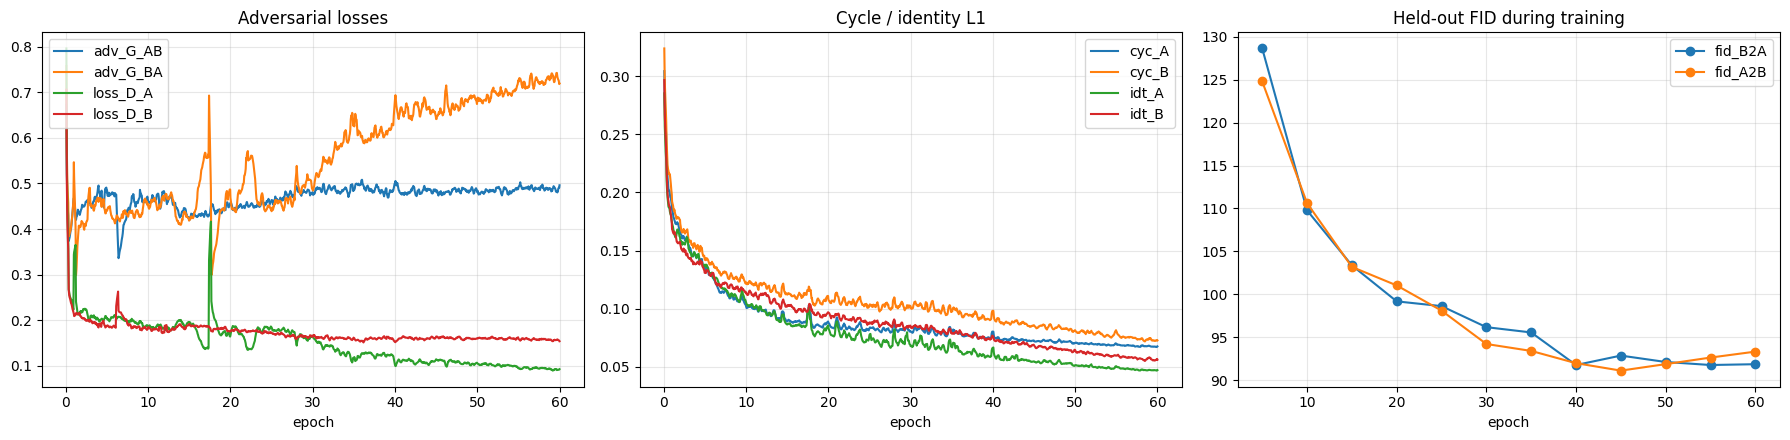

In [14]:
# loss curves again from the raw history (for the report / viva)
if len(hist):
    h = hist.copy(); ipe = train_summary.get("iters_per_epoch") or h["iter"].max()
    h["x"] = h["step"] / ipe
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
    for k in ["adv_G_AB", "adv_G_BA", "loss_D_A", "loss_D_B"]: ax[0].plot(h["x"], h[k].rolling(5, min_periods=1).mean(), label=k)
    ax[0].set_title("Adversarial losses")
    for k in ["cyc_A", "cyc_B", "idt_A", "idt_B"]: ax[1].plot(h["x"], h[k].rolling(5, min_periods=1).mean(), label=k)
    ax[1].set_title("Cycle / identity L1")
    if len(fidh):
        for k in ["fid_B2A", "fid_A2B"]: ax[2].plot(fidh["epoch"], fidh[k], marker="o", label=k)
    ax[2].set_title("Held-out FID during training")
    for a in ax: a.set_xlabel("epoch"); a.legend(); a.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(EVAL_DIR / "loss_and_fid_curves.png", dpi=120); plt.show()

# Part C — blinded human audit (30 fixed samples, 2 raters)
Creates `outputs/eval/<run>/human_audit/` with 30 side-by-side images (input | translation), a fixed random selection (seed 266, 15 per direction), shuffled and labelled `S01…S30` only. Each rater fills **their own copy** of the CSV independently (1–5 scale; artifacts: 5 = no artefacts). Re-run the last cell once both files are filled.

In [15]:
AUDIT_DIR = EVAL_DIR / "human_audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)
rng = random.Random(266)
a2b_pairs = list(zip(*paired(list_images(REAL_MONET), GEN_A2B)))
b2a_pairs = list(zip(*paired(take_n(list_images(REAL_PHOTO), N_EVAL), GEN_B2A)))
items = [("A2B", *p) for p in rng.sample(a2b_pairs, 15)] + [("B2A", *p) for p in rng.sample(b2a_pairs, 15)]
rng.shuffle(items)

key_rows = []
for i, (direction, inp, gen) in enumerate(items, 1):
    sid = f"S{i:02d}"
    canvas = Image.new("RGB", (522, 256), "white")
    canvas.paste(Image.open(inp).convert("RGB").resize((256, 256)), (0, 0))
    canvas.paste(Image.open(gen).convert("RGB").resize((256, 256)), (266, 0))
    canvas.save(AUDIT_DIR / f"{sid}.png")
    key_rows.append(dict(sample_id=sid, direction=direction, input=Path(inp).name, output=Path(gen).name))
pd.DataFrame(key_rows).to_csv(AUDIT_DIR / "audit_key_DO_NOT_SHOW_RATERS.csv", index=False)

for rater in ["rater1", "rater2"]:
    f = AUDIT_DIR / f"audit_{rater}.csv"
    if not f.exists():   # never overwrite filled-in ratings
        pd.DataFrame([dict(sample_id=r["sample_id"], style_1to5="", content_1to5="", artifacts_1to5="")
                      for r in key_rows]).to_csv(f, index=False)
print("Audit images + sheets in", AUDIT_DIR)

Audit images + sheets in /content/drive/MyDrive/DATA_266_Lab-1/Task-3/outputs/eval/cyclegan_r9_diffaug_ema/human_audit


In [16]:
def cohen_kappa(a, b, weights=None, labels=(1, 2, 3, 4, 5)):
    a, b = np.asarray(a, int), np.asarray(b, int)
    L = len(labels); idx = {l: i for i, l in enumerate(labels)}
    O = np.zeros((L, L))
    for x, y in zip(a, b):
        O[idx[x], idx[y]] += 1
    O /= O.sum()
    Ex = np.outer(O.sum(1), O.sum(0))
    i, j = np.meshgrid(range(L), range(L), indexing="ij")
    W = (i != j).astype(float) if weights is None else ((i - j) ** 2) / (L - 1) ** 2
    return float(1 - (W * O).sum() / max((W * Ex).sum(), 1e-12))

f1, f2 = AUDIT_DIR / "audit_rater1.csv", AUDIT_DIR / "audit_rater2.csv"
r1, r2 = pd.read_csv(f1), pd.read_csv(f2)
crit = ["style_1to5", "content_1to5", "artifacts_1to5"]
if r1[crit].notna().all().all() and r2[crit].notna().all().all():
    key = pd.read_csv(AUDIT_DIR / "audit_key_DO_NOT_SHOW_RATERS.csv")
    res = []
    for c in crit:
        a, b = r1[c].astype(int).values, r2[c].astype(int).values
        res.append(dict(criterion=c, mean_rater1=a.mean(), mean_rater2=b.mean(),
                        pct_exact_agreement=100 * (a == b).mean(), pct_within_1=100 * (abs(a - b) <= 1).mean(),
                        cohen_kappa=cohen_kappa(a, b), quadratic_weighted_kappa=cohen_kappa(a, b, "quadratic")))
    audit = pd.DataFrame(res)
    merged = key.merge(r1, on="sample_id").merge(r2, on="sample_id", suffixes=("_r1", "_r2"))
    for d in ["A2B", "B2A"]:
        sub = merged[merged.direction == d]
        print(d, {c: round(float((sub[c + "_r1"] + sub[c + "_r2"]).mean() / 2), 2) for c in crit})
    audit.to_csv(EVAL_DIR / "human_audit_results.csv", index=False)
    rep = pd.read_csv(PROJECT_DIR / "full_metrics_report.csv")
    rep = rep[rep.section != "human_audit"]
    extra = [dict(section="human_audit", metric=f"{r['criterion']}_{m}", direction="both", value=r[m], note="2 raters, 30 samples")
             for _, r in audit.iterrows() for m in ["mean_rater1", "mean_rater2", "pct_exact_agreement", "cohen_kappa", "quadratic_weighted_kappa"]]
    pd.concat([rep, pd.DataFrame(extra)]).to_csv(PROJECT_DIR / "full_metrics_report.csv", index=False)
    display(audit)
else:
    print("Ratings not filled in yet - fill audit_rater1.csv and audit_rater2.csv, then re-run this cell.")

Ratings not filled in yet - fill audit_rater1.csv and audit_rater2.csv, then re-run this cell.
